## Set Up

In [61]:
# IMPORTING REQUIRED PACKAGES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import itertools
import subprocess
from time import time
from scipy import stats
import scipy.optimize as opt  
from scipy.stats import chi2_contingency
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression as SKLR
from sklearn.linear_model import LinearRegression

In [62]:
# IMPORTING THE DATA

data = pd.read_csv("Train.csv")

# displaying the data
data.head()

,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,...,Compensation_and_Benefits,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
0,EID_23371,F,42.0,4,Married,Franklin,IT,Conceptual,4.0,4,...,type2,3.0,4,0.7516,1.8688,2.0,4,5,3,0.1841
1,EID_18000,M,24.0,3,Single,Springfield,Logistics,Analytical,5.0,4,...,type2,4.0,3,-0.9612,-0.4537,2.0,3,5,3,0.0670
2,EID_3891,F,58.0,3,Married,Clinton,Quality,Conceptual,27.0,3,...,type2,1.0,4,-0.9612,-0.4537,3.0,3,8,3,0.0851
3,EID_17492,F,26.0,3,Single,Lebanon,Human Resource Management,Behavioral,4.0,3,...,type2,1.0,3,-1.8176,-0.4537,NaN,3,7,3,0.0668
4,EID_22534,F,31.0,1,Married,Springfield,Logistics,Conceptual,5.0,4,...,type3,3.0,1,0.7516,-0.4537,2.0,2,8,2,0.1827


## Simple Exploratory Data Analysis

In [63]:
# GETTING THE DIMENSIONS OF THE DATA FRAME

data.shape

(7000, 24)

In [64]:
# DESCRIPTIVE STATISTICS

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                7000 non-null   object 
 1   Gender                     7000 non-null   object 
 2   Age                        6588 non-null   float64
 3   Education_Level            7000 non-null   int64  
 4   Relationship_Status        7000 non-null   object 
 5   Hometown                   7000 non-null   object 
 6   Unit                       7000 non-null   object 
 7   Decision_skill_possess     7000 non-null   object 
 8   Time_of_service            6856 non-null   float64
 9   Time_since_promotion       7000 non-null   int64  
 10  growth_rate                7000 non-null   int64  
 11  Travel_Rate                7000 non-null   int64  
 12  Post_Level                 7000 non-null   int64  
 13  Pay_Scale                  6991 non-null   float

In [65]:
# DESCRIBE THE DATA

data.describe()

,Age,Education_Level,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,Pay_Scale,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
count,6588.000000,7000.000000,6856.000000,7000.000000,7000.000000,7000.000000,7000.000000,6991.000000,6989.000000,7000.000000,6423.000000,7000.000000,6344.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,39.622799,3.187857,13.385064,2.367143,47.064286,0.817857,2.798000,6.006294,2.387895,3.098571,-0.008126,-0.013606,1.891078,2.834143,7.101286,3.257000,0.189376
std,13.606920,1.065102,10.364188,1.149395,15.761406,0.648205,1.163721,2.058435,1.122786,0.836377,0.989850,0.986933,0.529403,0.938945,1.164262,0.925319,0.185753
min,19.000000,1.000000,0.000000,0.000000,20.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-1.817600,-2.776200,1.000000,1.000000,5.000000,1.000000,0.000000
25%,27.000000,3.000000,5.000000,1.000000,33.000000,0.000000,2.000000,5.000000,1.000000,3.000000,-0.961200,-0.453700,2.000000,2.000000,6.000000,3.000000,0.070400
50%,37.000000,3.000000,10.000000,2.000000,47.000000,1.000000,3.000000,6.000000,2.000000,3.000000,-0.104800,-0.453700,2.000000,3.000000,7.000000,3.000000,0.142650
75%,52.000000,4.000000,21.000000,3.000000,61.000000,1.000000,3.000000,8.000000,3.000000,3.000000,0.751600,0.707500,2.000000,3.000000,8.000000,4.000000,0.235000
max,65.000000,5.000000,43.000000,4.000000,74.000000,2.000000,5.000000,10.000000,5.000000,5.000000,1.608100,1.868800,3.000000,5.000000,9.000000,5.000000,0.995900


## Dealing With Null Values

In [66]:
# CHECKING FOR NULL VALUES

data.isnull().sum()

Employee_ID                    0
Gender                         0
Age                          412
Education_Level                0
Relationship_Status            0
Hometown                       0
Unit                           0
Decision_skill_possess         0
Time_of_service              144
Time_since_promotion           0
growth_rate                    0
Travel_Rate                    0
Post_Level                     0
Pay_Scale                      9
Compensation_and_Benefits      0
Work_Life_balance             11
VAR1                           0
VAR2                         577
VAR3                           0
VAR4                         656
VAR5                           0
VAR6                           0
VAR7                           0
Attrition_rate                 0
dtype: int64

Because some of the null values are in specific variable types, it is best to replace the null values by the median value for that variable. For example, in the variable 'Age', all the values are whole, so it makes most sense to replace null values by other whole numbers, such as age's median. Additionally, no categorical variables have missing values, so all null values can be replaced by a numerical calculation of center (median).

In [67]:
# FILL MISSING VALUES

# for loop that goes through each variable
for var in data:
    
    # checking variable type (although the only variables with missing columns are type 'float', the program will get confused if it tries to execute the next line of code on categorical variables)
    if data[var].dtypes == 'float':
        
        # replacing missing values with the median of the variable
        data = data.fillna(data[var].median())

In [68]:
# CHECKING IF ANY NULL VALUES WERE MISSED

data.isnull().sum()

Employee_ID                  0
Gender                       0
Age                          0
Education_Level              0
Relationship_Status          0
Hometown                     0
Unit                         0
Decision_skill_possess       0
Time_of_service              0
Time_since_promotion         0
growth_rate                  0
Travel_Rate                  0
Post_Level                   0
Pay_Scale                    0
Compensation_and_Benefits    0
Work_Life_balance            0
VAR1                         0
VAR2                         0
VAR3                         0
VAR4                         0
VAR5                         0
VAR6                         0
VAR7                         0
Attrition_rate               0
dtype: int64

As seen above, all the null values were properly removed, so no further replacement of null values is needed.

## Encoding

In [69]:
# ONE HOT ENCODING

# Creating a copy as to keep the original values
dataohe = data.copy()

# Listing out the variables that will be encoded (notice they are all categorical with more than 2 categories)
category = ["Hometown", "Unit", "Decision_skill_possess", "Compensation_and_Benefits"]

# Initializing the encoder
onehot_encoder = OneHotEncoder(sparse=False)


# For loop that goes through each variable listed above and uses the encoder
for var in category:
    onehotdata = onehot_encoder.fit_transform(dataohe[[var]])
    onehotdf = pd.DataFrame(onehotdata)
    onehotdf.columns = list(onehot_encoder.categories_[0])
    
    # Adding the new encoded values to the data frame
    dataohe = pd.merge(
        left = dataohe,
        right = onehotdf,
        left_index = True,
        right_index = True,
        )

# Deleting the original, not encoded variables
dataohe = dataohe.drop('Hometown', axis=1)
dataohe = dataohe.drop('Unit', axis=1)
dataohe = dataohe.drop('Compensation_and_Benefits', axis=1)
dataohe = dataohe.drop('Decision_skill_possess', axis=1)

# Preview of new data frame
dataohe.head()

,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,...,Security,Analytical,Behavioral,Conceptual,Directive,type0,type1,type2,type3,type4
0,EID_23371,F,42.0,4,Married,4.0,4,33,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,EID_18000,M,24.0,3,Single,5.0,4,36,0,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,EID_3891,F,58.0,3,Married,27.0,3,51,0,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,EID_17492,F,26.0,3,Single,4.0,3,56,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,EID_22534,F,31.0,1,Married,5.0,4,62,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [70]:
# LABEL ENCODING

# Creating a copy as to keep the original values
datale = dataohe.copy()

# Listing out the variables that will be encoded (notice they are all categorical)
category = ["Gender", "Relationship_Status"]

# Initializing the encoder
labelencoder = LabelEncoder()

# For loop that goes through each variable listed above and uses the encoder
for i in category:
    datale[i] = labelencoder.fit_transform(datale[i])

# Preview of the new data frame
datale.head()

,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,...,Security,Analytical,Behavioral,Conceptual,Directive,type0,type1,type2,type3,type4
0,EID_23371,0,42.0,4,0,4.0,4,33,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,EID_18000,1,24.0,3,1,5.0,4,36,0,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,EID_3891,0,58.0,3,0,27.0,3,51,0,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,EID_17492,0,26.0,3,1,4.0,3,56,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,EID_22534,0,31.0,1,0,5.0,4,62,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


LABEL ENCODING KEY:

Gender: F = 0, M = 1

Relationship_Status: Married = 0, Single = 1

## Removing the 'Employee ID' Column

Because the 'Employee ID' is unique for each observation and doesn't* play a factor in the employee's 'Attrition_rate', the column is dropped for simplicity.

*Although the ID could play a factor in some ways (such as employees who have been working longer having a smaller number in their employee ID), it is still omitted because the method for assigning IDs is unknown. Additionally, it is fairly likely that if the ID plays a factor, it is due to a 'hidden variable' and not the ID itself. The vast majority of these possible 'hidden variables' are already included in the dataset.

In [71]:
# DROPPING 'EMPLOYEE ID'

# Dropping 'Employee_ID' from all data frames
data = data.drop('Employee_ID', axis=1)
dataohe = dataohe.drop('Employee_ID', axis=1)
datale = datale.drop('Employee_ID', axis=1)

# Previewing the new data frame
datale.head()

,Gender,Age,Education_Level,Relationship_Status,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,Pay_Scale,...,Security,Analytical,Behavioral,Conceptual,Directive,type0,type1,type2,type3,type4
0,0,42.0,4,0,4.0,4,33,1,1,7.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,24.0,3,1,5.0,4,36,0,3,6.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,58.0,3,0,27.0,3,51,0,2,8.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,26.0,3,1,4.0,3,56,1,3,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0,31.0,1,0,5.0,4,62,1,3,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Visualization

/var/folders/__/4jygz2pn6pd4k85qfnhh80zw0000gn/T/ipykernel_84759/4103895010.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax=ax, bins = 30)


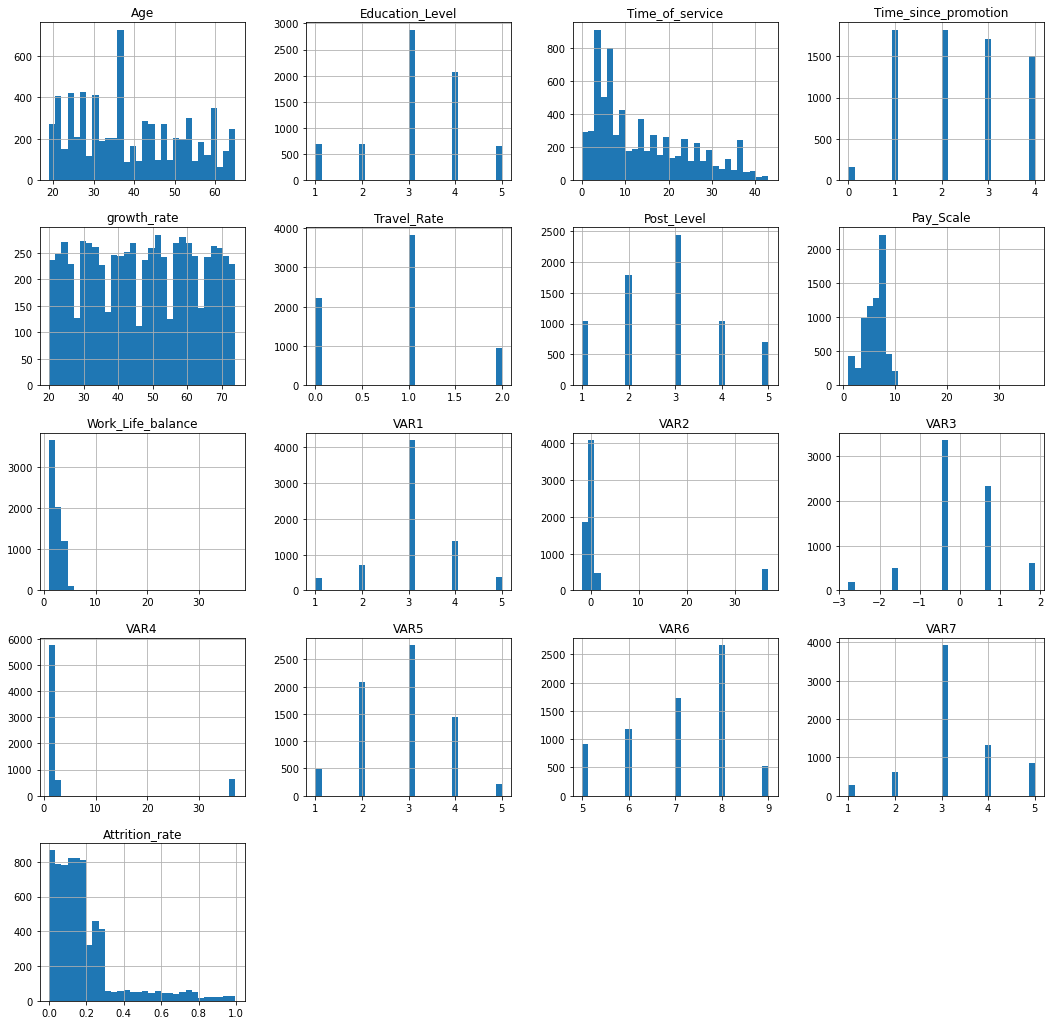

In [72]:
# PLOTTING HISTOGRAMS FOR ALL VARIABLES

fig = plt.figure(figsize=(18,18))
ax = fig.gca()
data.hist(ax=ax, bins = 30)
plt.show()

<AxesSubplot:>

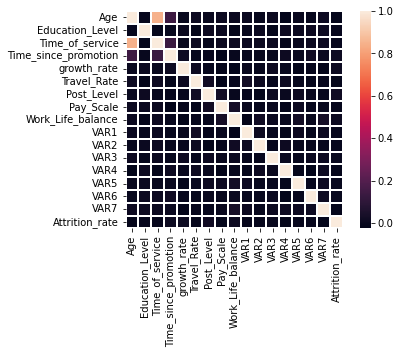

In [73]:
# MAKING A HEATMAP

# calculate the correlation matrix
corr = data.corr()

# correlation of variables
mask = np.zeros_like(corr)

# plot the heatmap
sns.heatmap(data = corr,
            mask = mask,
            linecolor = 'white',
            linewidth = 0.125,
            square = True)

## Lasso Model

In [85]:
#https://machinelearningmastery.com/lasso-regression-with-python/
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(x,y)
# define model evaluation method
crossval = RepeatedKFold(n_splits=30, n_repeats=5, random_state=1)
# evaluate model
scores = cross_val_score(lasso, x, y, scoring='neg_mean_absolute_error', cv=crossval, n_jobs=-1)
# force scores to be positive
MAE = abs(scores)
print('Mean MAE: %.3f (%.3f)' % (np.mean(MAE), np.std(MAE)))

Mean MAE: 0.127 (0.009)


In [92]:
score = 100 * max (0, 1 - np.mean(MAE))

print("Lasso Model Score Rating: ", score)

Lasso Model Score Rating:  87.33488295384419


## Random Forest

In [94]:
randomForest = RandomForestClassifier(1)
randomForest.fit(traindatax, traindatay)
y_pred = randomForest.predict(testdatax)
print("Accuracy of random forest classifier: ", randomForest.score(testdatax, testdatay))
confusion_matrix(testdatay, y_pred)

ValueError: Unknown label type: 'continuous'

In [100]:
from sklearn.metrics import mean_squared_error

mean_squared_error()


#score = 100 * max (0, 1 - np.mean(MAE))

#score = 100 * max (0, 1 - )


print("Random Forest Model Score Rating: ", score)

Random Forest Model Score Rating:  8.904761904761905


In [101]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(testdatay, y_pred, squared = False)


score = 100 * max (0, 1 - mse)


print("Random Forest Model Score Rating: ", score)

NameError: name 'y_pred' is not defined

Because the lasso had a higher score, we chose that one.